In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

ARQUIVO = ROOT / "data" / "processed" / "base_longitudinal.csv"

PASTA_FIGURAS = ROOT / "outputs" / "figures"
PASTA_TABELAS = ROOT / "outputs" / "tables"

base = pd.read_csv(ARQUIVO)

# GARANTE QUE OS INDICADORES ESTEJAM EM FORMATO NUMÉRICO

colunas_numericas = [
    "idade",
    "ano_ingresso",
    "fase_num",
    "inde",
    "iaa",
    "ieg",
    "ips",
    "ipp",
    "ida",
    "mat",
    "por",
    "ing",
    "ipv",
    "ian",
    "fase_ideal",
    "defasagem",
    "anos_na_pm",
    "defasagem_prox",
    "ida_prox",
    "ieg_prox",
    "ips_prox",
    "ipp_prox",
    "ipv_prox",
    "ian_prox",
    "inde_prox",
    "risco_prox_ano",
    "delta_ida",
    "delta_ieg",
    "delta_inde"
]

for coluna in colunas_numericas:
    if coluna in base.columns:
        base[coluna] = pd.to_numeric(
            base[coluna],
            errors="coerce"
        )

print(base.shape)
base.head()

(3030, 41)


,RA,fase_raw,idade,genero,ano_ingresso,instituicao,pedra,inde,iaa,ieg,...,ips_prox,ipp_prox,ipv_prox,ian_prox,inde_prox,pedra_prox,risco_prox_ano,delta_ida,delta_ieg,delta_inde
0,RA-1,7,19.0,Menina,2016,Escola Pública,Quartzo,5.783,8.3,4.1,...,NaN,NaN,NaN,10.0,NaN,NaN,0.0,NaN,NaN,NaN
1,RA-1,FASE 8,NaN,Feminino,2016,Privada *Parcerias com Bolsa 100%,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,10.0,NaN,NaN,0.0,NaN,NaN,NaN
2,RA-1,8E,21.0,Feminino,2021,Privada *Parcerias com Bolsa 100%,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RA-10,7,18.0,Menina,2021,Escola Pública,Quartzo,5.784,8.3,5.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RA-100,4,13.0,Menina,2019,Rede Decisão,Ametista,7.618,8.8,7.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



QUESTÃO 1 — DEFASAGEM


,ano,faixa_defasagem,alunos,percentual
0,2022,Defasagem moderada,573,66.627907
1,2022,Defasagem severa,28,3.255814
2,2022,Em fase / adiantado,259,30.116279
3,2023,Defasagem moderada,538,53.057199
4,2023,Defasagem severa,14,1.380671
5,2023,Em fase / adiantado,462,45.562130
6,2024,Defasagem moderada,531,45.934256
7,2024,Defasagem severa,3,0.259516
8,2024,Em fase / adiantado,622,53.806228


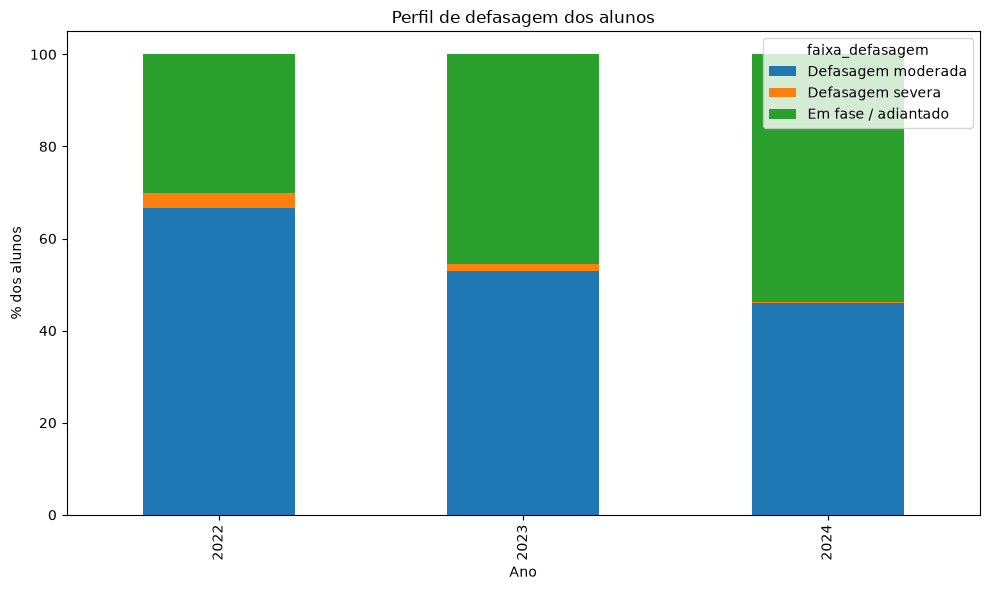


QUESTÃO 2 — IDA


,ano,fase_num,alunos,media,mediana
0,2022,0,190,7.140000,7.300000
1,2022,1,192,6.464062,6.800000
2,2022,2,155,5.406452,5.500000
3,2022,3,148,5.141892,5.200000
4,2022,4,76,6.052632,6.100000
5,2022,5,60,5.873333,6.550000
6,2022,6,18,6.694444,6.850000
7,2022,7,21,5.252381,5.000000
8,2023,0,231,7.422078,7.800000
9,2023,1,173,6.814451,6.900000



IDA GERAL POR ANO


,ano,alunos_validos,ida_medio,ida_mediano
0,2022,860,6.09,6.30
1,2023,937,6.66,6.80
2,2024,1055,6.35,6.75


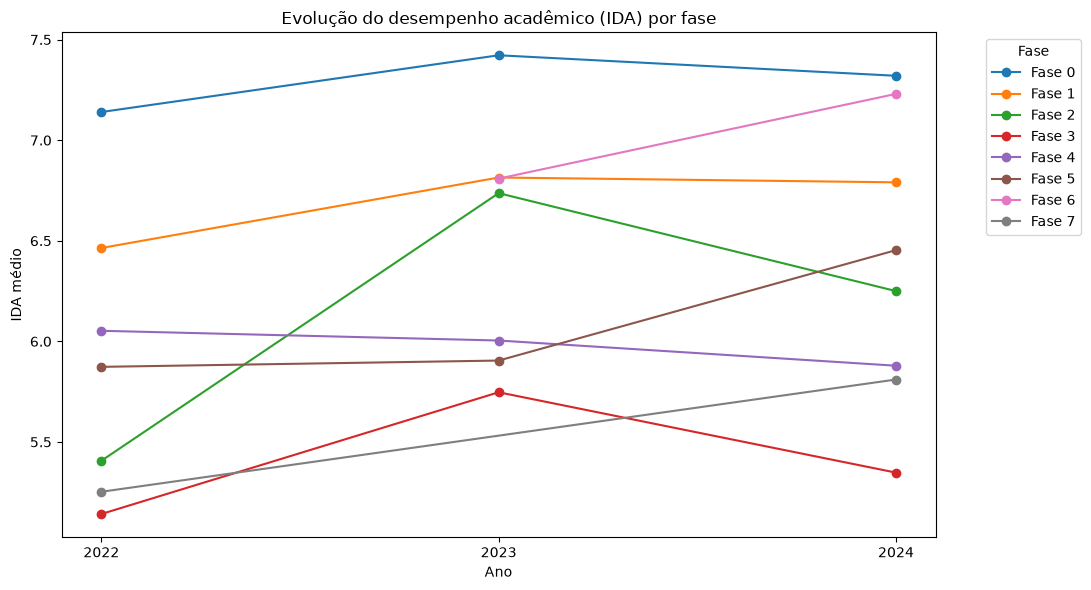


QUESTÃO 3 — ENGAJAMENTO


,ano,IEG_x_IDA,IEG_x_IPV
0,2022,0.507449,0.540334
1,2023,0.446479,0.492018
2,2024,0.516812,0.550950



QUESTÃO 4 — AUTOAVALIAÇÃO


,ano,IAA_x_IDA,IAA_x_IEG,gap_medio_absoluto,gap_medio_com_sinal,IAA_maior_IDA_%,IAA_menor_IDA_%
0,2022,0.183,0.234,2.738,2.182,85.000,13.721
1,2023,0.127,0.191,2.988,0.255,68.623,30.416
2,2024,0.178,0.230,2.551,2.194,86.053,13.852


In [6]:
# QUESTÃO 1 — IAN / DEFASAGEM

q1 = (
    base.groupby(
        ["ano", "faixa_defasagem"],
        dropna=False
    )
    .size()
    .rename("alunos")
    .reset_index()
)

q1["percentual"] = (
    q1["alunos"] /
    q1.groupby("ano")["alunos"].transform("sum")
    * 100
)

print("\nQUESTÃO 1 — DEFASAGEM")
display(q1)


# Gráfico
grafico_q1 = (
    q1.pivot(
        index="ano",
        columns="faixa_defasagem",
        values="percentual"
    )
)

grafico_q1.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel("% dos alunos")
plt.xlabel("Ano")
plt.title("Perfil de defasagem dos alunos")
plt.tight_layout()

plt.savefig(
    PASTA_FIGURAS / "01_defasagem_por_ano.png",
    dpi=300
)

plt.show()


# QUESTÃO 2 — IDA

q2 = (
    base.groupby(
        ["ano", "fase_num"]
    )["ida"]
    .agg(
        alunos="count",
        media="mean",
        mediana="median"
    )
    .reset_index()
)

print("\nQUESTÃO 2 — IDA")
display(q2)

# ============================================================
# COMPLEMENTO QUESTÃO 2 — EVOLUÇÃO DO IDA
# ============================================================

# Média geral por ano
q2_geral = (
    base.groupby("ano")["ida"]
    .agg(
        alunos_validos="count",
        ida_medio="mean",
        ida_mediano="median"
    )
    .reset_index()
)

print("\nIDA GERAL POR ANO")
display(
    q2_geral.round(2)
)


# Mantém somente fases com quantidade razoável de alunos
# para evitar conclusões baseadas em grupos muito pequenos
q2_grafico = q2[
    q2["alunos"] >= 20
].copy()


# Evolução por fase
plt.figure(figsize=(11, 6))

for fase in sorted(
    q2_grafico["fase_num"].dropna().unique()
):

    dados_fase = q2_grafico[
        q2_grafico["fase_num"] == fase
    ]

    plt.plot(
        dados_fase["ano"],
        dados_fase["media"],
        marker="o",
        label=f"Fase {int(fase)}"
    )

plt.title(
    "Evolução do desempenho acadêmico (IDA) por fase"
)

plt.xlabel("Ano")
plt.ylabel("IDA médio")

plt.xticks(
    [2022, 2023, 2024]
)

plt.legend(
    title="Fase",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    PASTA_FIGURAS /
    "02_ida_por_fase.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# FUNÇÃO AUXILIAR DE CORRELAÇÃO

def correlacao_spearman(df, x, y):

    dados = df[[x, y]].dropna()

    if len(dados) < 3:
        return np.nan

    return spearmanr(
        dados[x],
        dados[y]
    ).statistic


# QUESTÃO 3 — IEG x IDA / IPV

resultados_q3 = []

for ano in sorted(base["ano"].unique()):

    dados_ano = base[
        base["ano"] == ano
    ]

    resultados_q3.append({
        "ano": ano,
        "IEG_x_IDA": correlacao_spearman(
            dados_ano,
            "ieg",
            "ida"
        ),
        "IEG_x_IPV": correlacao_spearman(
            dados_ano,
            "ieg",
            "ipv"
        )
    })

q3 = pd.DataFrame(resultados_q3)

print("\nQUESTÃO 3 — ENGAJAMENTO")
display(q3)


# QUESTÃO 4 — IAA x IDA / IEG

# Diferença com sinal:
# positivo = IAA maior que IDA
# negativo = IAA menor que IDA

base["gap_iaa_ida"] = (
    base["iaa"] -
    base["ida"]
)

base["gap_abs_iaa_ida"] = (
    base["gap_iaa_ida"].abs()
)


resultados_q4 = []

for ano in sorted(
    base["ano"].unique()
):

    dados_ano = base[
        base["ano"] == ano
    ].copy()

    dados_gap = dados_ano[
        ["iaa", "ida"]
    ].dropna()

    gap = (
        dados_gap["iaa"] -
        dados_gap["ida"]
    )

    resultados_q4.append({

        "ano": ano,

        "IAA_x_IDA":
            correlacao_spearman(
                dados_ano,
                "iaa",
                "ida"
            ),

        "IAA_x_IEG":
            correlacao_spearman(
                dados_ano,
                "iaa",
                "ieg"
            ),

        "gap_medio_absoluto":
            gap.abs().mean(),

        "gap_medio_com_sinal":
            gap.mean(),

        "IAA_maior_IDA_%":
            (gap > 0).mean() * 100,

        "IAA_menor_IDA_%":
            (gap < 0).mean() * 100
    })


q4 = pd.DataFrame(
    resultados_q4
)

print(
    "\nQUESTÃO 4 — AUTOAVALIAÇÃO"
)

display(
    q4.round(3)
)

In [7]:
# ============================================================
# QUESTÕES 5 A 8
# IPS, IPP, IPV E MULTIDIMENSIONALIDADE DO INDE
# ============================================================


# ============================================================
# QUESTÃO 5 — IPS COMO POSSÍVEL SINAL ANTECEDENTE
# ============================================================

# Mantém somente pares realmente consecutivos:
# 2022 -> 2023
# 2023 -> 2024

longitudinal = base[
    base["ano_prox"] == base["ano"] + 1
].copy()


resultados_q5 = []

for ano in [2022, 2023]:

    dados = longitudinal[
        longitudinal["ano"] == ano
    ].copy()

    resultados_q5.append({
        "ano_origem": ano,

        "alunos": len(dados),

        "IPS_x_delta_IDA":
            correlacao_spearman(
                dados,
                "ips",
                "delta_ida"
            ),

        "IPS_x_delta_IEG":
            correlacao_spearman(
                dados,
                "ips",
                "delta_ieg"
            )
    })


q5 = pd.DataFrame(
    resultados_q5
)

print(
    "\nQUESTÃO 5 — IPS COMO SINAL ANTECEDENTE"
)

display(
    q5.round(3)
)


# ============================================================
# QUESTÃO 6 — IPP x IAN / DEFASAGEM
# ============================================================

# O IPP não está disponível de maneira equivalente
# para todos os anos. Portanto usamos somente registros
# em que o indicador existe.

dados_ipp = base[
    base["ipp"].notna()
].copy()


q6_medias = (
    dados_ipp.groupby(
        ["ano", "faixa_defasagem"]
    )["ipp"]
    .agg(
        alunos="count",
        ipp_medio="mean",
        ipp_mediano="median"
    )
    .reset_index()
)


print(
    "\nQUESTÃO 6 — IPP POR SITUAÇÃO DE DEFASAGEM"
)

display(
    q6_medias.round(3)
)


resultados_q6 = []

for ano in sorted(
    dados_ipp["ano"].unique()
):

    dados = dados_ipp[
        dados_ipp["ano"] == ano
    ]

    resultados_q6.append({
        "ano": ano,

        "alunos_com_IPP":
            dados["ipp"].notna().sum(),

        "IPP_x_IAN":
            correlacao_spearman(
                dados,
                "ipp",
                "ian"
            ),

        "IPP_x_defasagem":
            correlacao_spearman(
                dados,
                "ipp",
                "defasagem"
            )
    })


q6 = pd.DataFrame(
    resultados_q6
)

print(
    "\nCORRELAÇÕES DO IPP"
)

display(
    q6.round(3)
)


# ============================================================
# QUESTÃO 7 — QUAIS INDICADORES MAIS SE ASSOCIAM AO IPV?
# ============================================================

indicadores_ipv = [
    "ida",
    "ieg",
    "iaa",
    "ips",
    "ipp"
]


resultados_q7 = []

for ano in sorted(
    base["ano"].unique()
):

    dados = base[
        base["ano"] == ano
    ]

    for indicador in indicadores_ipv:

        correlacao = (
            correlacao_spearman(
                dados,
                indicador,
                "ipv"
            )
        )

        resultados_q7.append({
            "ano": ano,

            "indicador":
                indicador.upper(),

            "correlacao_com_IPV":
                correlacao,

            "forca_abs":
                abs(correlacao)
                if pd.notna(correlacao)
                else np.nan
        })


q7 = pd.DataFrame(
    resultados_q7
)


print(
    "\nQUESTÃO 7 — INDICADORES ASSOCIADOS AO IPV"
)

display(
    q7.sort_values(
        [
            "ano",
            "forca_abs"
        ],
        ascending=[
            True,
            False
        ]
    ).round(3)
)


# ============================================================
# QUESTÃO 8 — MULTIDIMENSIONALIDADE DO INDE
# ============================================================

# Como o IPP não está disponível de forma consistente
# em 2022, esta análise utiliza 2023 e 2024.

features_inde = [
    "ida",
    "ieg",
    "ips",
    "ipp"
]


dados_inde = (
    base[
        base["ano"].isin(
            [2023, 2024]
        )
    ][
        features_inde +
        ["inde"]
    ]
    .dropna()
)


print(
    "\nObservações utilizadas na análise do INDE:",
    len(dados_inde)
)


X = dados_inde[
    features_inde
]

y = dados_inde[
    "inde"
]


# Padronização permite comparar coeficientes
scaler_x = StandardScaler()

scaler_y = StandardScaler()


X_std = scaler_x.fit_transform(
    X
)

y_std = scaler_y.fit_transform(
    y.to_numpy().reshape(
        -1,
        1
    )
).ravel()


reg = LinearRegression()

reg.fit(
    X_std,
    y_std
)


q8 = pd.DataFrame({
    "indicador": [
        indicador.upper()
        for indicador in features_inde
    ],

    "coeficiente_padronizado":
        reg.coef_
})


q8["importancia_abs"] = (
    q8[
        "coeficiente_padronizado"
    ]
    .abs()
)


q8 = q8.sort_values(
    "importancia_abs",
    ascending=False
)


print(
    "\nQUESTÃO 8 — ASSOCIAÇÃO COM O INDE"
)

display(
    q8.round(3)
)


# ============================================================
# QUALIDADE GLOBAL DA REGRESSÃO
# ============================================================

r2_inde = reg.score(
    X_std,
    y_std
)

print(
    f"\nR² da regressão com IDA + IEG + IPS + IPP: "
    f"{r2_inde:.3f}"
)


QUESTÃO 5 — IPS COMO SINAL ANTECEDENTE


,ano_origem,alunos,IPS_x_delta_IDA,IPS_x_delta_IEG
0,2022,600,0.029,-0.024
1,2023,765,0.027,0.020



QUESTÃO 6 — IPP POR SITUAÇÃO DE DEFASAGEM


,ano,faixa_defasagem,alunos,ipp_medio,ipp_mediano
0,2023,Defasagem moderada,536,7.505,7.500
1,2023,Defasagem severa,14,6.957,7.578
2,2023,Em fase / adiantado,388,7.665,7.812
3,2024,Defasagem moderada,531,7.413,7.500
4,2024,Defasagem severa,3,7.260,7.031
5,2024,Em fase / adiantado,520,7.688,7.708



CORRELAÇÕES DO IPP


...


QUESTÃO 7 — INDICADORES ASSOCIADOS AO IPV


,ano,indicador,correlacao_com_IPV,forca_abs
0,2022,IDA,0.624,0.624
1,2022,IEG,0.540,0.540
2,2022,IAA,0.245,0.245
3,2022,IPS,0.190,0.190
4,2022,IPP,NaN,NaN
5,2023,IDA,0.551,0.551
9,2023,IPP,0.512,0.512
6,2023,IEG,0.492,0.492
7,2023,IAA,0.155,0.155
8,2023,IPS,0.072,0.072



Observações utilizadas na análise do INDE: 1985

QUESTÃO 8 — ASSOCIAÇÃO COM O INDE


,indicador,coeficiente_padronizado,importancia_abs
0,IDA,0.469,0.469
1,IEG,0.401,0.401
2,IPS,0.240,0.240
3,IPP,0.221,0.221



R² da regressão com IDA + IEG + IPS + IPP: 0.823



QUESTÃO 10 — EVOLUÇÃO


,variavel,periodo,alunos,media_inicial,media_final,variacao_media,percentual_melhorou
0,INDE,2022-2023,600,7.262788,7.235771,-0.024755,46.833333
1,INDE,2023-2024,765,7.455472,7.390440,-0.050061,44.705882
2,IDA,2022-2023,600,6.467333,6.602613,0.115157,44.666667
3,IDA,2023-2024,765,6.825685,6.310967,-0.478446,37.647059
4,IEG,2022-2023,600,8.300833,8.556272,0.234843,55.500000
5,IEG,2023-2024,765,8.864791,7.260537,-0.946544,28.366013
6,IAN,2022-2023,600,6.525000,6.920833,0.395833,18.333333
7,IAN,2023-2024,765,7.405229,7.977124,0.571895,22.875817
8,DEFASAGEM,2022-2023,600,-0.891667,-0.735000,0.156667,30.833333
9,DEFASAGEM,2023-2024,765,-0.589542,-0.324183,0.265359,40.915033



TRANSIÇÃO ENTRE PEDRAS


pedra_prox,Ametista,Quartzo,Topázio,Ágata
pedra,,,,
Ametista,47.7,5.4,25.8,21.1
Quartzo,11.1,41.1,0.0,47.8
Topázio,32.0,0.7,62.6,4.8
Ágata,28.8,18.4,5.8,46.9



QUESTÃO 11 — DEFASAGEM POR FASE


,ano,fase_num,alunos,alunos_defasados,percentual_defasados
0,2022,0,190,121,63.68
1,2022,1,192,162,84.38
2,2022,2,155,111,71.61
3,2022,3,148,82,55.41
4,2022,4,76,50,65.79
5,2022,5,60,44,73.33
7,2022,7,21,16,76.19
8,2023,0,231,117,50.65
9,2023,1,173,132,76.30
10,2023,2,200,124,62.00



FASES COM MAIOR PERCENTUAL DE DEFASAGEM


,ano,fase_num,alunos,alunos_defasados,percentual_defasados
1,2022,1,192,162,84.38
7,2022,7,21,16,76.19
5,2022,5,60,44,73.33
2,2022,2,155,111,71.61
4,2022,4,76,50,65.79
0,2022,0,190,121,63.68
3,2022,3,148,82,55.41
9,2023,1,173,132,76.30
14,2023,6,33,24,72.73
13,2023,5,65,41,63.08


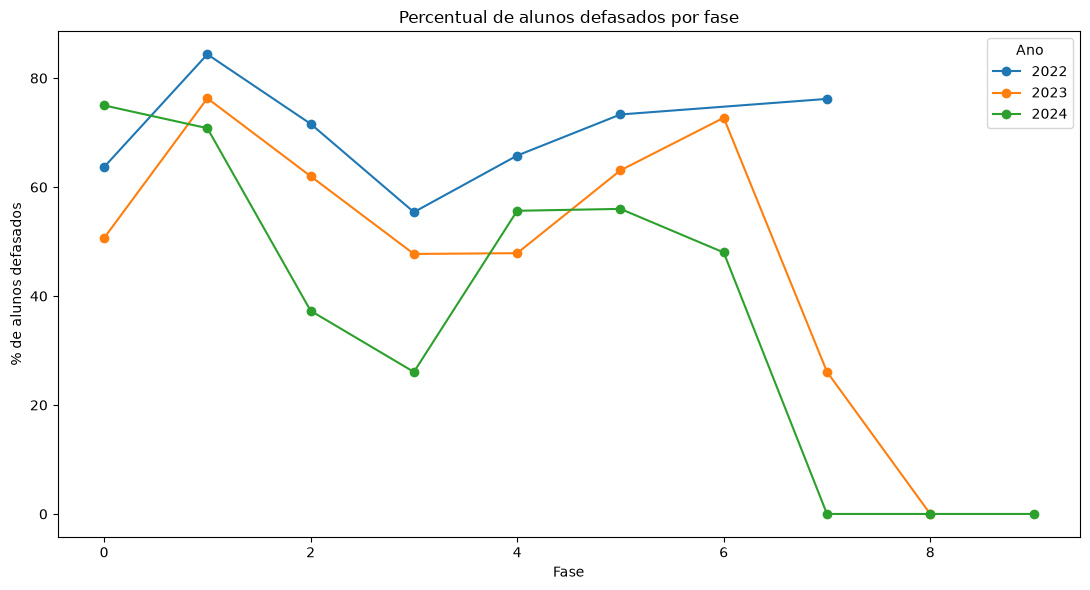


Questão 11 exportada.


In [9]:
# QUESTÃO 10 — EVOLUÇÃO LONGITUDINAL

def comparar_anos(df, variavel, ano1, ano2):

    a = (
        df[df["ano"] == ano1]
        [["RA", variavel]]
        .rename(
            columns={
                variavel: f"{variavel}_{ano1}"
            }
        )
    )

    b = (
        df[df["ano"] == ano2]
        [["RA", variavel]]
        .rename(
            columns={
                variavel: f"{variavel}_{ano2}"
            }
        )
    )

    pares = a.merge(
        b,
        on="RA",
        how="inner"
    )

    pares["delta"] = (
        pares[f"{variavel}_{ano2}"] -
        pares[f"{variavel}_{ano1}"]
    )

    return {
        "variavel": variavel.upper(),
        "periodo": f"{ano1}-{ano2}",
        "alunos": len(pares),
        "media_inicial":
            pares[f"{variavel}_{ano1}"].mean(),
        "media_final":
            pares[f"{variavel}_{ano2}"].mean(),
        "variacao_media":
            pares["delta"].mean(),
        "percentual_melhorou":
            (pares["delta"] > 0).mean() * 100
    }


resultados_q10 = []

for variavel in [
    "inde",
    "ida",
    "ieg",
    "ian",
    "defasagem"
]:

    resultados_q10.append(
        comparar_anos(
            base,
            variavel,
            2022,
            2023
        )
    )

    resultados_q10.append(
        comparar_anos(
            base,
            variavel,
            2023,
            2024
        )
    )

q10 = pd.DataFrame(resultados_q10)

print("\nQUESTÃO 10 — EVOLUÇÃO")
display(q10)


# TRANSIÇÃO ENTRE PEDRAS

pedras = longitudinal[
    longitudinal["pedra"].notna() &
    longitudinal["pedra_prox"].notna()
]

transicao_pedras = pd.crosstab(
    pedras["pedra"],
    pedras["pedra_prox"],
    normalize="index"
).mul(100).round(1)

print("\nTRANSIÇÃO ENTRE PEDRAS")
display(transicao_pedras)


# QUESTÃO 11 — INSIGHT EXTRA
# DEFASAGEM POR FASE

q11 = (
    base[
        base["fase_num"].notna()
    ]
    .groupby(
        ["ano", "fase_num"]
    )
    .agg(
        alunos=("RA", "count"),
        alunos_defasados=(
            "risco_atual",
            "sum"
        ),
        percentual_defasados=(
            "risco_atual",
            "mean"
        )
    )
    .reset_index()
)

q11["percentual_defasados"] = (
    q11["percentual_defasados"]
    * 100
)


# Evita conclusões baseadas em grupos muito pequenos
q11_analise = q11[
    q11["alunos"] >= 20
].copy()


print(
    "\nQUESTÃO 11 — DEFASAGEM POR FASE"
)

display(
    q11_analise.round(2)
)


# IDENTIFICA AS FASES COM MAIOR RISCO EM CADA ANO

ranking_q11 = (
    q11_analise
    .sort_values(
        [
            "ano",
            "percentual_defasados"
        ],
        ascending=[
            True,
            False
        ]
    )
)


print(
    "\nFASES COM MAIOR PERCENTUAL DE DEFASAGEM"
)

display(
    ranking_q11.round(2)
)


# GRÁFICO

plt.figure(
    figsize=(11, 6)
)

for ano in sorted(
    q11_analise["ano"].unique()
):

    dados = q11_analise[
        q11_analise["ano"] == ano
    ]

    plt.plot(
        dados["fase_num"],
        dados["percentual_defasados"],
        marker="o",
        label=str(ano)
    )


plt.title(
    "Percentual de alunos defasados por fase"
)

plt.xlabel(
    "Fase"
)

plt.ylabel(
    "% de alunos defasados"
)

plt.legend(
    title="Ano"
)

plt.tight_layout()

plt.savefig(
    PASTA_FIGURAS /
    "11_defasagem_por_fase.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# EXPORTAÇÃO

q11_analise.to_csv(
    PASTA_TABELAS /
    "q11_defasagem_por_fase.csv",
    index=False
)

print(
    "\nQuestão 11 exportada."
)